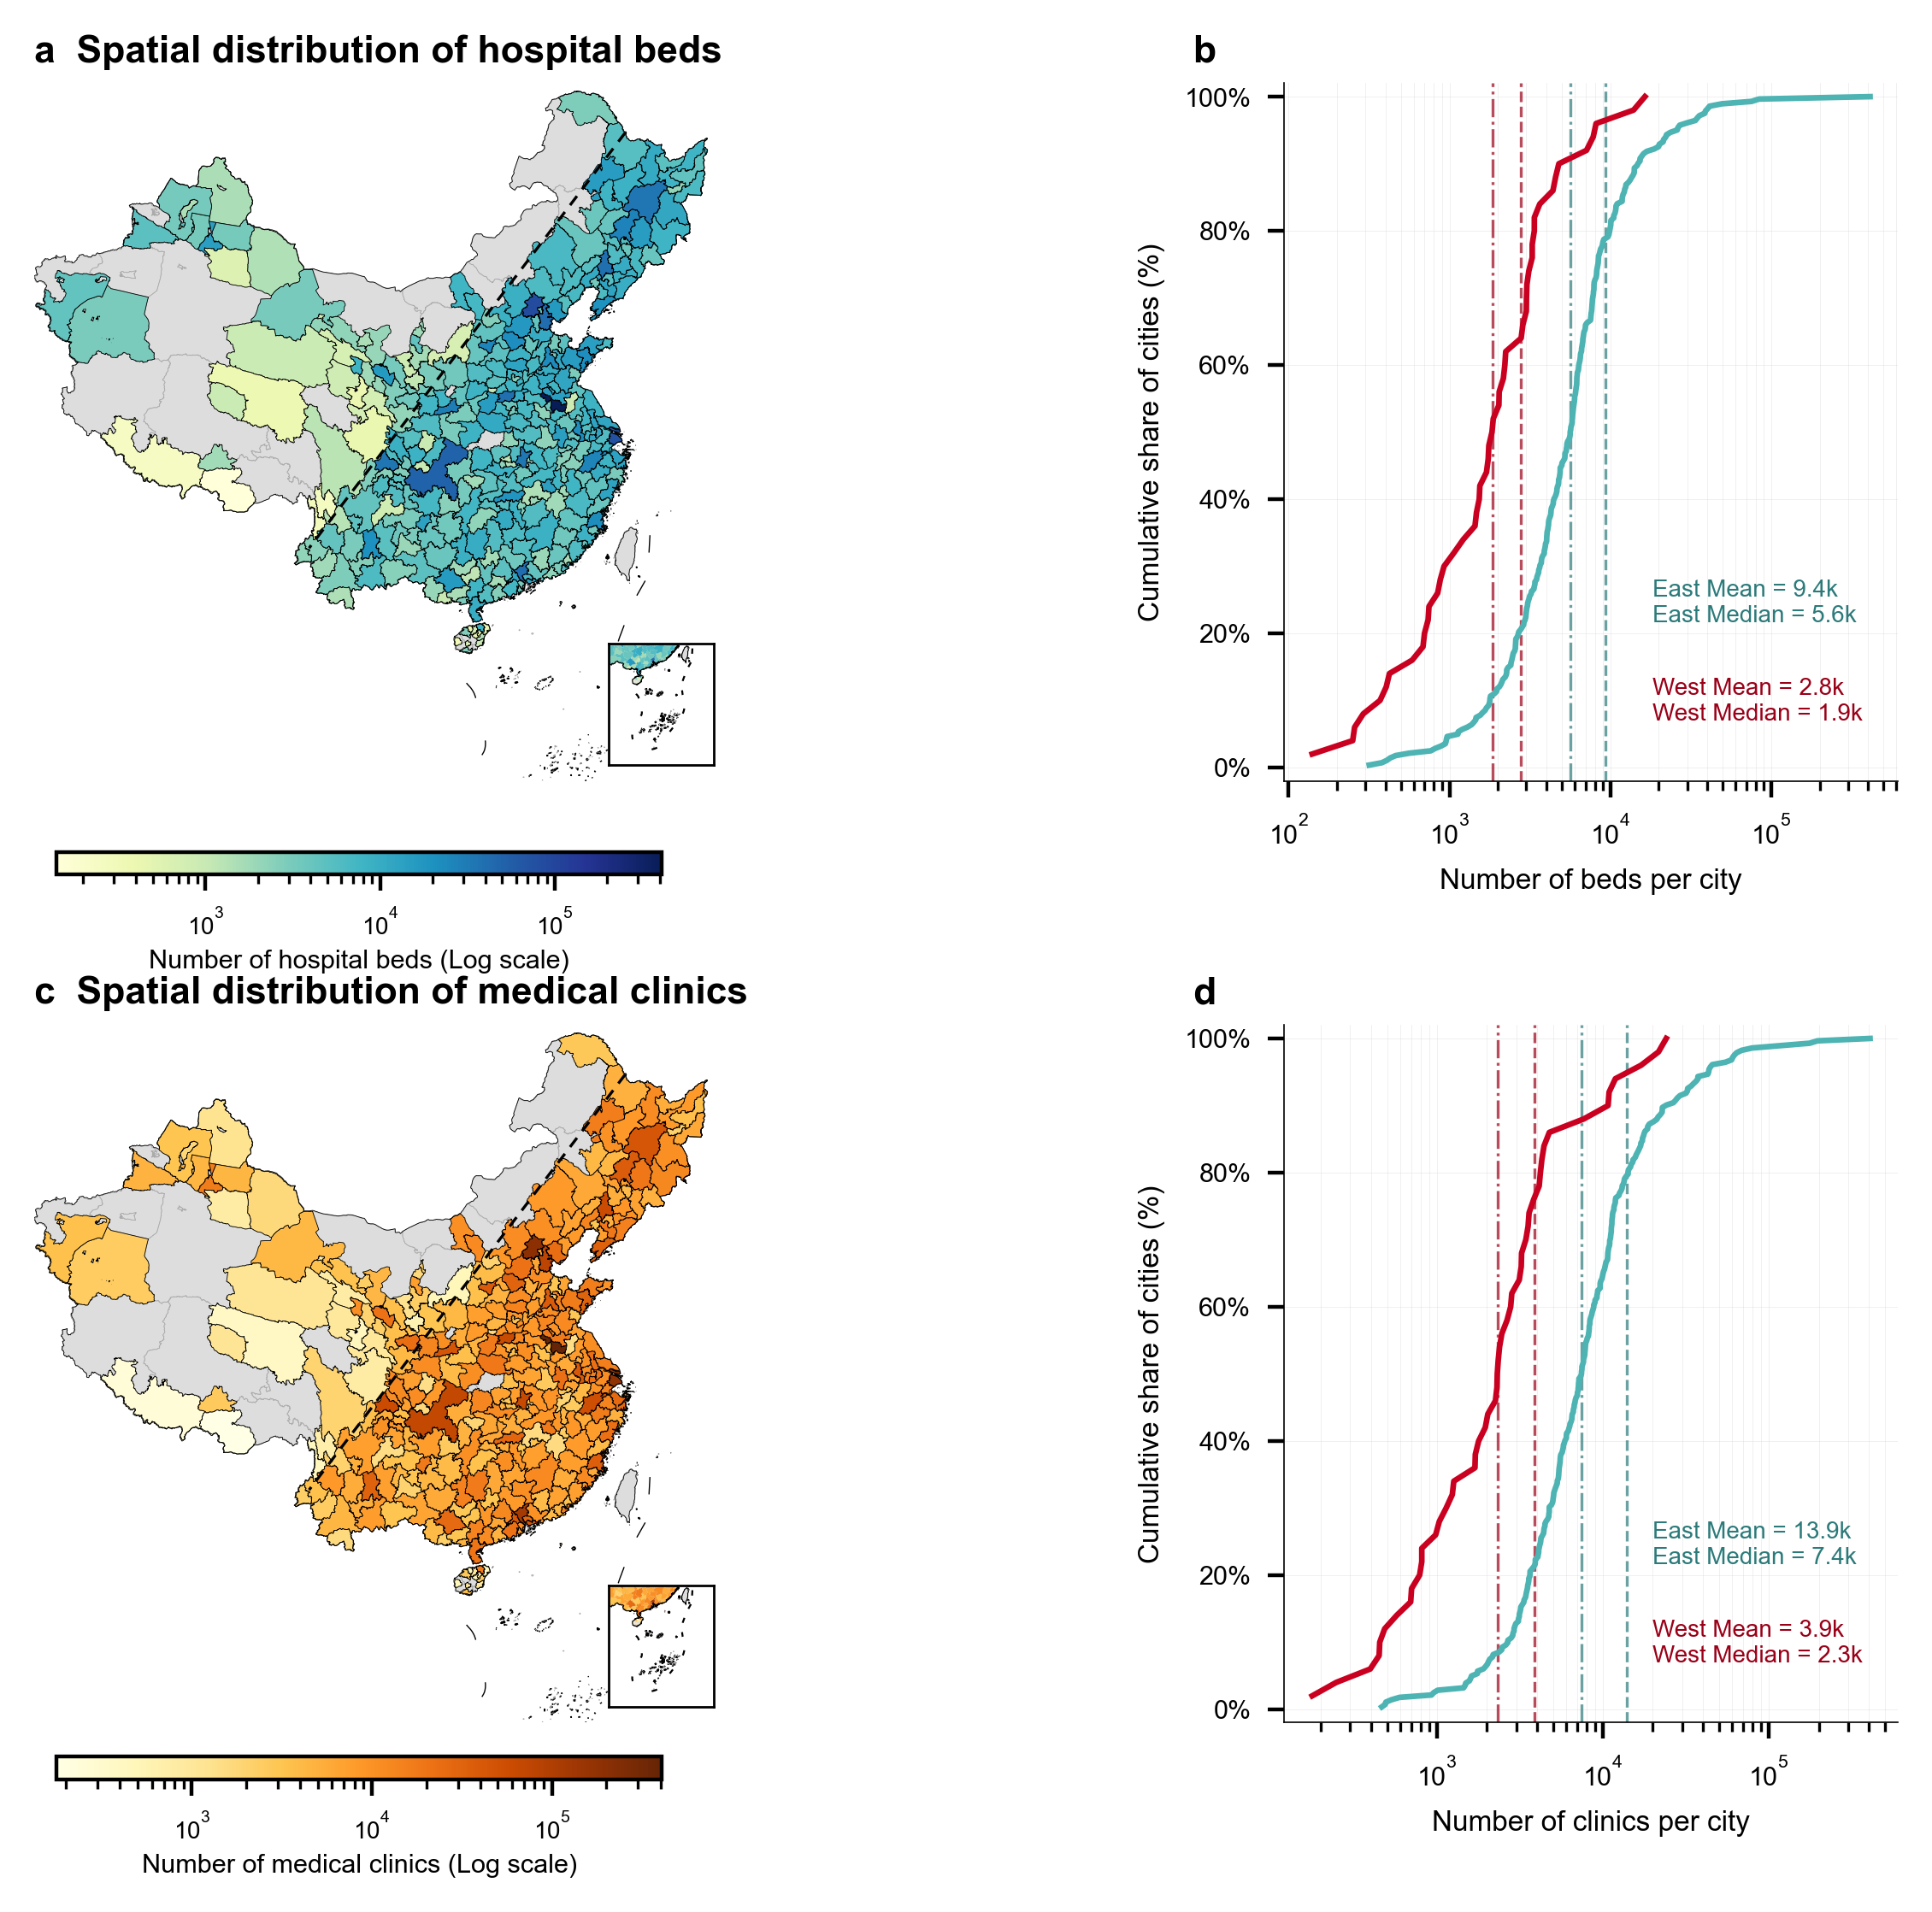

✓ 调整完成！格式完美的学术多维矩阵图已成功保存至 → /Users/shirley/Desktop/plots_V2/FigS4_healthcare_CDF_final.png


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from shapely.geometry import box as shapely_box
from pyproj import Transformer

# ── 0. Paths & settings ───────────────────────────────────────────────────────
INPUT_FILE = Path("/13-National hospital directory.xlsx")
SHP_PATH   = Path("/city_shp/shi_en.shp")
CHINA_SHP  = Path("/中国底图/中国面.shp")
CHINA_SHP2 = Path("/九段线/九段线和群岛.shp")
OUTFILE    = Path("/FigS4_healthcare_CDF_final.png")

PROJ_STR = "+proj=aea +lat_1=25 +lat_2=47 +lat_0=0 +lon_0=105"

CITY_NAME_MAP = {
    "Wulumuqi":  "Urumqi",
    "Xian":      "Xi'an",
    "Qiqihaer":  "Qiqihar",
    "Huhehaote": "Hohhot",
    "Haerbin":   "Harbin",
}

# ── 1. Global style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "Arial",
    "font.size":        6,
    "axes.titlesize":   7,
    "axes.titleweight": "bold",
    "axes.titlepad":    4,
})

# ── 2. Spatial data & Hu Line Split ───────────────────────────────────────────
china_border = gpd.read_file(CHINA_SHP).to_crs(PROJ_STR)
jiudanline   = gpd.read_file(CHINA_SHP2).to_crs(PROJ_STR)

city_shp_raw = gpd.read_file(SHP_PATH)
city_shp_raw["English"] = city_shp_raw["English"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
city_shp = city_shp_raw.to_crs(PROJ_STR)

_hhy_transformer = Transformer.from_crs("EPSG:4326", PROJ_STR, always_xy=True)
_HHY_X, _HHY_Y  = _hhy_transformer.transform([127.5, 98.5], [50.2, 25.0])

_NANHAI_BOUNDS = (
    gpd.GeoDataFrame(geometry=[shapely_box(105, 2, 122, 24)], crs="EPSG:4326")
    .to_crs(PROJ_STR).total_bounds
)

_hhy_x0, _hhy_y0 = _HHY_X[0], _HHY_Y[0]
_hhy_x1, _hhy_y1 = _HHY_X[1], _HHY_Y[1]

def _hhy_x_at_y(y):
    t = (y - _hhy_y1) / (_hhy_y0 - _hhy_y1)
    return _hhy_x1 + t * (_hhy_x0 - _hhy_x1)

_cx = city_shp.geometry.centroid.x
_cy = city_shp.geometry.centroid.y
city_shp["region"] = np.where(_cx > _hhy_x_at_y(_cy), "East", "West")

# ── 3. Data Loader ────────────────────────────────────────────────────────────
def load_healthcare_data():
    df = pd.read_excel(INPUT_FILE, sheet_name="fig4")
    df = df[["city", "beds", "clinics"]].copy()
    df["beds"]    = pd.to_numeric(df["beds"],    errors="coerce")
    df["clinics"] = pd.to_numeric(df["clinics"], errors="coerce")
    df = df.dropna(subset=["city"])
    df["city"] = df["city"].str.strip().map(lambda x: CITY_NAME_MAP.get(x, x))
    return df.groupby("city")[["beds", "clinics"]].sum()

res_df = load_healthcare_data()
map_df = city_shp.merge(res_df, left_on="English", right_on="city", how="left")

# ── 4. Plotting Components ────────────────────────────────────────────────────
def add_nanhai_inset(parent_ax, col, norm, cmap):
    x1, y1, x2, y2 = _NANHAI_BOUNDS
    axins = parent_ax.inset_axes([0.82, 0.02, 0.15, 0.18])
    axins.set_facecolor("white")
    
    city_shp.plot(ax=axins, color="#DDDDDD", linewidth=0)
    map_df.plot(column=col, ax=axins, cmap=cmap, norm=norm, linewidth=0)
    china_border.plot(ax=axins, facecolor="none", edgecolor="black", linewidth=0.2)
    jiudanline.plot(ax=axins, edgecolor="black", linewidth=0.4)
    
    pad_x = (x2 - x1) * 0.08
    pad_y = (y2 - y1) * 0.08
    axins.set_xlim(x1 - pad_x, x2 + pad_x)
    axins.set_ylim(y1 - pad_y, y2 + pad_y)
    axins.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in axins.spines.values():
        spine.set_linewidth(0.5)
        spine.set_color("black")

def draw_map_panel(ax, col, title, panel_tag, norm, cmap):
    city_shp.plot(ax=ax, color="#DDDDDD", linewidth=0.15, edgecolor="#AAAAAA")
    map_df.plot(column=col, ax=ax, cmap=cmap, norm=norm, linewidth=0.15, edgecolor="black")
    china_border.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.15)
    jiudanline.plot(ax=ax, edgecolor="black", linewidth=0.25)
    
    ax.plot(_HHY_X, _HHY_Y, color="black", linewidth=0.6, linestyle="--", dashes=(4, 3), zorder=5)
    
    xmin, ymin, xmax, ymax = china_border.total_bounds
    height = ymax - ymin
    width  = xmax - xmin
    ax.set_xlim(xmin, xmax + width * 0.04)
    ax.set_ylim(ymin + height * 0.10, ymax + height * 0.01)
    ax.set_axis_off()
    
    ax.text(0, 1.02, f"{panel_tag}  {title}", transform=ax.transAxes,
            fontsize=8, fontweight="bold", va="bottom", ha="left")
    
    add_nanhai_inset(ax, col, norm, cmap)

def draw_cdf_panel(ax, col, panel_tag, x_label):
    """绘制带 Mean/Median 统计特征线的 CDF 曲线"""
    east_vals = map_df[map_df["region"] == "East"][col].dropna().values
    west_vals = map_df[map_df["region"] == "West"][col].dropna().values
    
    # 1. 绘制 East 曲线及统计线 (浅青色系)
    if len(east_vals) > 0:
        sorted_east = np.sort(east_vals)
        y_east = np.arange(1, len(sorted_east) + 1) / len(sorted_east)
        ax.plot(sorted_east, y_east * 100, color="#4db3b3", lw=1.2, label="East", zorder=4)
        
        # 计算特征值
        mean_e = np.mean(east_vals)
        med_e = np.median(east_vals)
        
        # 绘制垂直虚线
        ax.axvline(mean_e, color="#2c7a7a", ls="--", lw=0.6, alpha=0.7, zorder=2)
        ax.axvline(med_e, color="#2c7a7a", ls="-.", lw=0.6, alpha=0.7, zorder=2)
        
        # 文本标注 (右下角集中呈现，防止对数轴上多条线上的文字重叠重合)
        stats_text_e = f"East Mean = {mean_e/1000:.1f}k\nEast Median = {med_e/1000:.1f}k"
        ax.text(0.6, 0.22, stats_text_e, transform=ax.transAxes, fontsize=5, color="#2c7a7a", va="bottom")
        
    # 2. 绘制 West 曲线及统计线 (深红色系)
    if len(west_vals) > 0:
        sorted_west = np.sort(west_vals)
        y_west = np.arange(1, len(sorted_west) + 1) / len(sorted_west)
        ax.plot(sorted_west, y_west * 100, color="#ca0020", lw=1.2, label="West", zorder=4)
        
        # 计算特征值
        mean_w = np.mean(west_vals)
        med_w = np.median(west_vals)
        
        # 绘制垂直虚线
        ax.axvline(mean_w, color="#9a0018", ls="--", lw=0.6, alpha=0.7, zorder=2)
        ax.axvline(med_w, color="#9a0018", ls="-.", lw=0.6, alpha=0.7, zorder=2)
        
        # 文本标注
        stats_text_w = f"West Mean = {mean_w/1000:.1f}k\nWest Median = {med_w/1000:.1f}k"
        ax.text(0.6, 0.08, stats_text_w, transform=ax.transAxes, fontsize=5, color="#9a0018", va="bottom")
    
    # 样式精调
    ax.set_ylabel("Cumulative share of cities (%)", fontsize=6)
    ax.set_xlabel(x_label, fontsize=6)
    ax.set_ylim(-2, 102)
    ax.set_xscale('log')
    
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f"{int(v)}%"))
    ax.tick_params(axis='both', labelsize=5.5)

    
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(0.3)
    ax.grid(True, which="both", linewidth=0.15, color="lightgrey", alpha=0.4)
    
    ax.text(-0.15, 1.02, panel_tag, transform=ax.transAxes, fontsize=8, fontweight='bold', va='bottom', ha='left')

# ── 5. Canvas Grid Layout (2 Rows × 2 Cols) ──────────────────────────────────
W_IN = 18 / 2.54   
H_IN = 14.0 / 2.54 

fig = plt.figure(figsize=(W_IN, H_IN), dpi=400, facecolor="white")

gs = GridSpec(2, 2, figure=fig, width_ratios=[2.8, 1.2], hspace=0.35, wspace=0.18,
              left=0.04, right=0.96, top=0.95, bottom=0.08)

ax_map_beds = fig.add_subplot(gs[0, 0])
ax_cdf_beds = fig.add_subplot(gs[0, 1])
ax_map_clin = fig.add_subplot(gs[1, 0])
ax_cdf_clin = fig.add_subplot(gs[1, 1])

# ── 6. Rendering Maps & CDFs ──────────────────────────────────────────────────
valid_beds = map_df["beds"].dropna()
norm_beds  = LogNorm(vmin=max(1, valid_beds.min()), vmax=valid_beds.max())

valid_clin = map_df["clinics"].dropna()
norm_clin  = LogNorm(vmin=max(1, valid_clin.min()), vmax=valid_clin.max())

# Row 1: Hospital Beds
draw_map_panel(ax_map_beds, "beds", "Spatial distribution of hospital beds", "a", norm_beds, "YlGnBu")
draw_cdf_panel(ax_cdf_beds, "beds", "b", "Number of beds per city")

# Row 2: Medical Clinics
draw_map_panel(ax_map_clin, "clinics", "Spatial distribution of medical clinics", "c", norm_clin, "YlOrBr")
draw_cdf_panel(ax_cdf_clin, "clinics", "d", "Number of clinics per city")

# ── 7. Optimized Legend Placement (Proportional Alignment) ────────────────────

cax_beds = fig.add_axes([0.2, 0.53, 0.25, 0.012])
sm_beds = mcm.ScalarMappable(cmap="YlGnBu", norm=norm_beds)
cbar_beds = fig.colorbar(sm_beds, cax=cax_beds, orientation="horizontal")
cbar_beds.ax.tick_params(labelsize=5)
cbar_beds.set_label("Number of hospital beds (Log scale)", fontsize=5.5, labelpad=2)


cax_clin = fig.add_axes([0.2, 0.05, 0.25, 0.012])
sm_clin = mcm.ScalarMappable(cmap="YlOrBr", norm=norm_clin)
cbar_clin = fig.colorbar(sm_clin, cax=cax_clin, orientation="horizontal")
cbar_clin.ax.tick_params(labelsize=5)
cbar_clin.set_label("Number of medical clinics (Log scale)", fontsize=5.5, labelpad=2)

# ── 8. Export & Save ──────────────────────────────────────────────────────────
OUTFILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTFILE, dpi=400, bbox_inches="tight", facecolor="white")
plt.show()
